In [2]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

path = kagglehub.dataset_download("guillemservera/global-daily-climate-data")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\naouf\.cache\kagglehub\datasets\guillemservera\global-daily-climate-data\versions\20


##Chargement Data

In [5]:

weather_path = os.path.join(path, "daily_weather.parquet")
df_weather = pd.read_parquet(weather_path, engine="fastparquet")

df_weather = df_weather[df_weather['date'].dt.year ==2022]
df_weather.head(2)


,station_id,city_name,date,season,avg_temp_c,min_temp_c,max_temp_c,precipitation_mm,snow_depth_mm,avg_wind_dir_deg,avg_wind_speed_kmh,peak_wind_gust_kmh,avg_sea_level_pres_hpa,sunshine_total_min
0,41515,Asadabad,2022-01-01,Winter,4.5,1.0,9.4,0.7,NaN,26.0,3.8,NaN,1026.2,NaN
0,41515,Asadabad,2022-01-02,Winter,4.3,0.2,8.0,4.1,NaN,100.0,2.5,NaN,1023.7,NaN


In [9]:
df_weather.tail(5)

,station_id,city_name,date,season,avg_temp_c,min_temp_c,max_temp_c,precipitation_mm,snow_depth_mm,avg_wind_dir_deg,avg_wind_speed_kmh,peak_wind_gust_kmh,avg_sea_level_pres_hpa,sunshine_total_min
448525,67975,Masvingo,2022-12-27,Summer,23.9,17.1,29.1,0.0,NaN,140.0,10.2,NaN,1017.0,NaN
448526,67975,Masvingo,2022-12-28,Summer,24.4,17.2,29.9,1.2,NaN,132.0,8.6,NaN,1016.2,NaN
448527,67975,Masvingo,2022-12-29,Summer,25.4,17.4,32.0,0.0,NaN,101.0,6.2,NaN,1014.0,NaN
448528,67975,Masvingo,2022-12-30,Summer,25.4,18.7,36.0,0.0,NaN,128.0,13.0,NaN,1016.8,NaN
448529,67975,Masvingo,2022-12-31,Summer,20.8,17.7,23.4,3.9,NaN,152.0,17.5,NaN,1020.8,NaN


In [7]:
df_weather.info()

<class 'pandas.DataFrame'>
Index: 448530 entries, 0 to 0
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   station_id              448530 non-null  category      
 1   city_name               448165 non-null  category      
 2   date                    448530 non-null  datetime64[ns]
 3   season                  448530 non-null  category      
 4   avg_temp_c              448495 non-null  float64       
 5   min_temp_c              446438 non-null  float64       
 6   max_temp_c              448186 non-null  float64       
 7   precipitation_mm        408503 non-null  float64       
 8   snow_depth_mm           45277 non-null   float64       
 9   avg_wind_dir_deg        439825 non-null  float64       
 10  avg_wind_speed_kmh      441542 non-null  float64       
 11  peak_wind_gust_kmh      66731 non-null   float64       
 12  avg_sea_level_pres_hpa  441409 non-null  float64   

In [8]:
df_weather = df_weather.reset_index(drop=True)

In [10]:
df_weather.shape

(448530, 14)

In [11]:
df_weather.dtypes

station_id                      category
city_name                       category
date                      datetime64[ns]
season                          category
avg_temp_c                       float64
min_temp_c                       float64
max_temp_c                       float64
precipitation_mm                 float64
snow_depth_mm                    float64
avg_wind_dir_deg                 float64
avg_wind_speed_kmh               float64
peak_wind_gust_kmh               float64
avg_sea_level_pres_hpa           float64
sunshine_total_min               float64
dtype: object

In [12]:
df_weather.describe()

,date,avg_temp_c,min_temp_c,max_temp_c,precipitation_mm,snow_depth_mm,avg_wind_dir_deg,avg_wind_speed_kmh,peak_wind_gust_kmh,avg_sea_level_pres_hpa,sunshine_total_min
count,448530,448495.000000,446438.000000,448186.000000,408503.000000,45277.000000,439825.000000,441542.000000,66731.000000,441409.000000,5450.000000
mean,2022-07-02 02:14:41.760417280,17.897158,12.931993,23.247151,3.010800,98.828434,176.941265,10.763786,34.876019,1014.457488,341.215046
min,2022-01-01 00:00:00,-47.500000,-50.000000,-45.800000,0.000000,0.000000,0.000000,0.000000,0.000000,957.600000,0.000000
25%,2022-04-02 00:00:00,11.200000,6.000000,16.400000,0.000000,0.000000,77.000000,6.500000,24.100000,1009.900000,69.000000
50%,2022-07-02 00:00:00,20.400000,14.800000,26.300000,0.000000,0.000000,181.000000,9.400000,31.500000,1013.700000,307.000000
75%,2022-10-01 00:00:00,26.500000,21.900000,31.700000,1.800000,51.000000,272.000000,13.500000,42.000000,1018.800000,582.000000
max,2022-12-31 00:00:00,44.300000,38.100000,56.000000,462.300000,4750.000000,360.000000,99.200000,360.000000,1061.300000,968.000000
std,NaN,10.766830,10.651793,11.358560,9.222261,349.714809,108.859256,6.197216,16.633594,7.483482,277.983119


##Sélections et indexation

In [13]:
df_weather[["city_name","date"]].head()

,city_name,date
0,Asadabad,2022-01-01
1,Asadabad,2022-01-02
2,Asadabad,2022-01-03
3,Asadabad,2022-01-04
4,Asadabad,2022-01-05


In [14]:
df_weather.loc[10:20, ["city_name", "date"]]

,city_name,date
10,Asadabad,2022-01-11
11,Asadabad,2022-01-12
12,Asadabad,2022-01-13
13,Asadabad,2022-01-14
14,Asadabad,2022-01-15
15,Asadabad,2022-01-16
16,Asadabad,2022-01-17
17,Asadabad,2022-01-18
18,Asadabad,2022-01-19
19,Asadabad,2022-01-20


In [15]:
df_weather.iloc[10:20,3:6]

,season,avg_temp_c,min_temp_c
10,Winter,1.7,-1.0
11,Winter,2.2,-0.7
12,Winter,1.3,-1.0
13,Winter,1.1,-2.5
14,Winter,2.7,-0.2
15,Winter,5.4,1.7
16,Winter,5.5,4.0
17,Winter,6.2,2.0
18,Winter,5.3,1.4
19,Winter,5.1,0.1


In [16]:
df_weather[df_weather["city_name"] == "Paris"].head()

,station_id,city_name,date,season,avg_temp_c,min_temp_c,max_temp_c,precipitation_mm,snow_depth_mm,avg_wind_dir_deg,avg_wind_speed_kmh,peak_wind_gust_kmh,avg_sea_level_pres_hpa,sunshine_total_min
115288,07149,Paris,2022-01-01,Winter,9.9,6.4,14.1,0.3,NaN,170.0,6.9,27.8,1024.8,NaN
115289,07149,Paris,2022-01-02,Winter,11.2,8.7,13.6,NaN,NaN,211.0,17.3,48.0,1019.2,NaN
115290,07149,Paris,2022-01-03,Winter,11.3,10.4,12.7,0.0,NaN,218.0,19.5,50.0,1015.7,NaN
115291,07149,Paris,2022-01-04,Winter,8.6,4.3,11.8,20.6,NaN,253.0,18.1,54.0,1002.1,NaN
115292,07149,Paris,2022-01-05,Winter,3.4,1.2,8.4,2.8,NaN,273.0,14.2,38.9,1014.5,NaN


In [17]:
df_weather[(df_weather["city_name"] == "Paris") & (df_weather["avg_temp_c"] > 30)].head()

,station_id,city_name,date,season,avg_temp_c,min_temp_c,max_temp_c,precipitation_mm,snow_depth_mm,avg_wind_dir_deg,avg_wind_speed_kmh,peak_wind_gust_kmh,avg_sea_level_pres_hpa,sunshine_total_min
115487,07149,Paris,2022-07-19,Summer,30.8,22.0,40.3,0.0,NaN,133.0,13.9,52.0,1013.7,NaN


In [18]:
df_weather.query(
    "city_name == 'Paris' and avg_temp_c > 30"
).head()

,station_id,city_name,date,season,avg_temp_c,min_temp_c,max_temp_c,precipitation_mm,snow_depth_mm,avg_wind_dir_deg,avg_wind_speed_kmh,peak_wind_gust_kmh,avg_sea_level_pres_hpa,sunshine_total_min
115487,07149,Paris,2022-07-19,Summer,30.8,22.0,40.3,0.0,NaN,133.0,13.9,52.0,1013.7,NaN


In [19]:
df_weather[(df_weather["city_name"] == "Paris") & (df_weather["avg_wind_speed_kmh"].notna())].head()

,station_id,city_name,date,season,avg_temp_c,min_temp_c,max_temp_c,precipitation_mm,snow_depth_mm,avg_wind_dir_deg,avg_wind_speed_kmh,peak_wind_gust_kmh,avg_sea_level_pres_hpa,sunshine_total_min
115288,07149,Paris,2022-01-01,Winter,9.9,6.4,14.1,0.3,NaN,170.0,6.9,27.8,1024.8,NaN
115289,07149,Paris,2022-01-02,Winter,11.2,8.7,13.6,NaN,NaN,211.0,17.3,48.0,1019.2,NaN
115290,07149,Paris,2022-01-03,Winter,11.3,10.4,12.7,0.0,NaN,218.0,19.5,50.0,1015.7,NaN
115291,07149,Paris,2022-01-04,Winter,8.6,4.3,11.8,20.6,NaN,253.0,18.1,54.0,1002.1,NaN
115292,07149,Paris,2022-01-05,Winter,3.4,1.2,8.4,2.8,NaN,273.0,14.2,38.9,1014.5,NaN


##Manipulation des colonnes et lignes

In [23]:
df_work = df_weather.copy()
df_work.rename(columns={
    "city_name": "ville",
    "season": "saison"
}, inplace=True)

df_work.head()


,station_id,ville,date,saison,avg_temp_c,min_temp_c,max_temp_c,precipitation_mm,snow_depth_mm,avg_wind_dir_deg,avg_wind_speed_kmh,peak_wind_gust_kmh,avg_sea_level_pres_hpa,sunshine_total_min
0,41515,Asadabad,2022-01-01,Winter,4.5,1.0,9.4,0.7,NaN,26.0,3.8,NaN,1026.2,NaN
1,41515,Asadabad,2022-01-02,Winter,4.3,0.2,8.0,4.1,NaN,100.0,2.5,NaN,1023.7,NaN
2,41515,Asadabad,2022-01-03,Winter,4.8,2.0,7.7,2.4,NaN,103.0,4.4,NaN,1020.8,NaN
3,41515,Asadabad,2022-01-04,Winter,4.3,0.7,6.3,7.8,NaN,105.0,3.1,NaN,1017.2,NaN
4,41515,Asadabad,2022-01-05,Winter,3.9,0.2,5.7,11.4,NaN,92.0,2.0,NaN,1016.9,NaN


In [24]:
df_work["etendue_temp"] = df_work["max_temp_c"] - df_work["min_temp_c"]
df_work.head()

,station_id,ville,date,saison,avg_temp_c,min_temp_c,max_temp_c,precipitation_mm,snow_depth_mm,avg_wind_dir_deg,avg_wind_speed_kmh,peak_wind_gust_kmh,avg_sea_level_pres_hpa,sunshine_total_min,etendue_temp
0,41515,Asadabad,2022-01-01,Winter,4.5,1.0,9.4,0.7,NaN,26.0,3.8,NaN,1026.2,NaN,8.4
1,41515,Asadabad,2022-01-02,Winter,4.3,0.2,8.0,4.1,NaN,100.0,2.5,NaN,1023.7,NaN,7.8
2,41515,Asadabad,2022-01-03,Winter,4.8,2.0,7.7,2.4,NaN,103.0,4.4,NaN,1020.8,NaN,5.7
3,41515,Asadabad,2022-01-04,Winter,4.3,0.7,6.3,7.8,NaN,105.0,3.1,NaN,1017.2,NaN,5.6
4,41515,Asadabad,2022-01-05,Winter,3.9,0.2,5.7,11.4,NaN,92.0,2.0,NaN,1016.9,NaN,5.5


In [25]:
def temperature_level(temp):
    if pd.isna(temp):
        return "Unknown"
    elif temp < 10:
        return "Cold"
    elif temp < 20:
        return "Mild"
    elif temp < 30:
        return "Warm"
    else:
        return "Hot"

df_work["temp_level"] = df_work["avg_temp_c"].apply(temperature_level)
df_work.head()


,station_id,ville,date,saison,avg_temp_c,min_temp_c,max_temp_c,precipitation_mm,snow_depth_mm,avg_wind_dir_deg,avg_wind_speed_kmh,peak_wind_gust_kmh,avg_sea_level_pres_hpa,sunshine_total_min,etendue_temp,temp_level
0,41515,Asadabad,2022-01-01,Winter,4.5,1.0,9.4,0.7,NaN,26.0,3.8,NaN,1026.2,NaN,8.4,Cold
1,41515,Asadabad,2022-01-02,Winter,4.3,0.2,8.0,4.1,NaN,100.0,2.5,NaN,1023.7,NaN,7.8,Cold
2,41515,Asadabad,2022-01-03,Winter,4.8,2.0,7.7,2.4,NaN,103.0,4.4,NaN,1020.8,NaN,5.7,Cold
3,41515,Asadabad,2022-01-04,Winter,4.3,0.7,6.3,7.8,NaN,105.0,3.1,NaN,1017.2,NaN,5.6,Cold
4,41515,Asadabad,2022-01-05,Winter,3.9,0.2,5.7,11.4,NaN,92.0,2.0,NaN,1016.9,NaN,5.5,Cold


In [26]:
df_work["temp_level"].value_counts()

temp_level
Warm       203686
Mild       118711
Cold        99655
Hot         26443
Unknown        35
Name: count, dtype: int64

In [27]:
df_work = df_work.drop(columns=["sunshine_total_min"])
list(df_work.columns)

['station_id',
 'ville',
 'date',
 'saison',
 'avg_temp_c',
 'min_temp_c',
 'max_temp_c',
 'precipitation_mm',
 'snow_depth_mm',
 'avg_wind_dir_deg',
 'avg_wind_speed_kmh',
 'peak_wind_gust_kmh',
 'avg_sea_level_pres_hpa',
 'etendue_temp',
 'temp_level']

In [28]:
df_work.sort_values(by="avg_temp_c", ascending=False).head()

,station_id,ville,date,saison,avg_temp_c,min_temp_c,max_temp_c,precipitation_mm,snow_depth_mm,avg_wind_dir_deg,avg_wind_speed_kmh,peak_wind_gust_kmh,avg_sea_level_pres_hpa,etendue_temp,temp_level
174210,40665,Kut,2022-08-06,Summer,44.3,37.5,50.3,0.0,NaN,336.0,24.9,NaN,995.1,12.8,Hot
174208,40665,Kut,2022-08-04,Summer,44.1,36.0,50.8,0.0,NaN,324.0,21.7,NaN,999.1,14.8,Hot
202279,40582,Hawalli,2022-07-20,Summer,43.9,38.0,49.0,0.0,NaN,352.0,22.6,NaN,996.4,11.0,Hot
174209,40665,Kut,2022-08-05,Summer,43.9,37.5,50.1,0.0,NaN,324.0,32.4,NaN,997.2,12.6,Hot
174211,40665,Kut,2022-08-07,Summer,43.8,38.1,49.3,0.0,NaN,327.0,29.2,NaN,994.7,11.2,Hot


##Nettoyage

In [29]:
# Vérification
df_work.isna().sum()


station_id                     0
ville                        365
date                           0
saison                         0
avg_temp_c                    35
min_temp_c                  2092
max_temp_c                   344
precipitation_mm           40027
snow_depth_mm             403253
avg_wind_dir_deg            8705
avg_wind_speed_kmh          6988
peak_wind_gust_kmh        381799
avg_sea_level_pres_hpa      7121
etendue_temp                2236
temp_level                     0
dtype: int64

In [30]:
print("=== Lignes contenant des NaN ===")
df_work[df_work.isna().any(axis=1)].head()

=== Lignes contenant des NaN ===


,station_id,ville,date,saison,avg_temp_c,min_temp_c,max_temp_c,precipitation_mm,snow_depth_mm,avg_wind_dir_deg,avg_wind_speed_kmh,peak_wind_gust_kmh,avg_sea_level_pres_hpa,etendue_temp,temp_level
0,41515,Asadabad,2022-01-01,Winter,4.5,1.0,9.4,0.7,NaN,26.0,3.8,NaN,1026.2,8.4,Cold
1,41515,Asadabad,2022-01-02,Winter,4.3,0.2,8.0,4.1,NaN,100.0,2.5,NaN,1023.7,7.8,Cold
2,41515,Asadabad,2022-01-03,Winter,4.8,2.0,7.7,2.4,NaN,103.0,4.4,NaN,1020.8,5.7,Cold
3,41515,Asadabad,2022-01-04,Winter,4.3,0.7,6.3,7.8,NaN,105.0,3.1,NaN,1017.2,5.6,Cold
4,41515,Asadabad,2022-01-05,Winter,3.9,0.2,5.7,11.4,NaN,92.0,2.0,NaN,1016.9,5.5,Cold


In [31]:
# Remplacement par la moyenne
mean_avg_temp_c= df_work["avg_temp_c"].mean()
print(f"Moyenne de avg_temp_c: {mean_avg_temp_c:.3f}")

df_work["avg_temp_c"] = df_work["avg_temp_c"].fillna(mean_avg_temp_c)

print("\nAprès fillna:")
print(df_work.isna().sum())

Moyenne de avg_temp_c: 17.897

Après fillna:
station_id                     0
ville                        365
date                           0
saison                         0
avg_temp_c                     0
min_temp_c                  2092
max_temp_c                   344
precipitation_mm           40027
snow_depth_mm             403253
avg_wind_dir_deg            8705
avg_wind_speed_kmh          6988
peak_wind_gust_kmh        381799
avg_sea_level_pres_hpa      7121
etendue_temp                2236
temp_level                     0
dtype: int64


In [32]:
df_work = df_work.dropna()
print("\nAprès drop na:")
print(df_work.isna().sum())


Après drop na:
station_id                0
ville                     0
date                      0
saison                    0
avg_temp_c                0
min_temp_c                0
max_temp_c                0
precipitation_mm          0
snow_depth_mm             0
avg_wind_dir_deg          0
avg_wind_speed_kmh        0
peak_wind_gust_kmh        0
avg_sea_level_pres_hpa    0
etendue_temp              0
temp_level                0
dtype: int64


In [ ]:
df_work.duplicated().sum()
#df_work = df_work.drop_duplicates()

np.int64(0)

##Agrégations ,groupby et timeseries

In [34]:
df_work.groupby('saison').mean(numeric_only=True)

,avg_temp_c,min_temp_c,max_temp_c,precipitation_mm,snow_depth_mm,avg_wind_dir_deg,avg_wind_speed_kmh,peak_wind_gust_kmh,avg_sea_level_pres_hpa,etendue_temp
saison,,,,,,,,,,
Autumn,8.793666,5.686203,12.209533,2.547288,14.492004,184.592976,12.523048,35.043242,1014.954657,6.523330
Spring,6.372681,1.724771,11.190367,1.604664,221.721967,187.584353,13.462589,37.834735,1017.239883,9.465596
Summer,17.859193,12.779523,23.079083,2.074569,7.236697,199.172844,11.608183,35.447743,1016.108147,10.299560
Winter,-0.134051,-3.132246,2.795608,2.740270,171.842357,204.229615,16.066384,43.301805,1013.784236,5.927854


In [ ]:
df_work.groupby('saison')['avg_temp_c'].mean()

saison
Autumn     8.793666
Spring     6.372681
Summer    17.859193
Winter    -0.134051
Name: avg_temp_c, dtype: float64

In [36]:
stats = df_work.groupby("saison")['avg_temp_c'].agg(["mean", "std", "min", "max"])
stats



,mean,std,min,max
saison,,,,
Autumn,8.793666,6.435737,-17.9,22.8
Spring,6.372681,6.721383,-20.4,24.9
Summer,17.859193,4.876037,2.6,29.7
Winter,-0.134051,5.987008,-26.0,15.7


In [37]:
percentiles = df_work.groupby("saison")["avg_temp_c"].quantile([0.25, 0.5, 0.75]).unstack()
percentiles.columns = ["Q1 (25%)", "Médiane (50%)", "Q3 (75%)"]
percentiles

,Q1 (25%),Médiane (50%),Q3 (75%)
saison,,,
Autumn,4.7,10.2,13.5
Spring,1.7,6.8,11.0
Summer,15.4,18.1,21.3
Winter,-3.5,0.6,3.9


In [38]:
#df_work = df_work.reset_index(drop=True)
df_date_index = df_work.copy()

df_date_index["date"] = pd.to_datetime(df_date_index["date"])

In [39]:
df_date_index = df_date_index.set_index("date")

In [40]:
hourly = df_date_index.resample("h").mean(numeric_only=True)

hourly.head()

,avg_temp_c,min_temp_c,max_temp_c,precipitation_mm,snow_depth_mm,avg_wind_dir_deg,avg_wind_speed_kmh,peak_wind_gust_kmh,avg_sea_level_pres_hpa,etendue_temp
date,,,,,,,,,,
2022-01-01 00:00:00,3.158333,0.283333,6.139583,2.345833,139.708333,212.354167,15.002083,36.49375,1018.041667,5.85625
2022-01-01 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-01 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-01 03:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-01 04:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [41]:
daily = df_date_index.resample("d").mean(numeric_only=True)

daily[["avg_temp_c"]].head()

C:\Users\naouf\AppData\Local\Temp\ipykernel_5748\2132596080.py:1: Pandas4Warning: 'd' is deprecated and will be removed in a future version, please use 'D' instead.
  daily = df_date_index.resample("d").mean(numeric_only=True)


,avg_temp_c
date,
2022-01-01,3.158333
2022-01-02,2.776744
2022-01-03,2.717391
2022-01-04,2.143478
2022-01-05,-1.008333


In [42]:
weekly = df_date_index.resample("w").mean(numeric_only=True)

weekly[["avg_temp_c"]].head()

C:\Users\naouf\AppData\Local\Temp\ipykernel_5748\2689021027.py:1: Pandas4Warning: 'w' is deprecated and will be removed in a future version, please use 'W' instead.
  weekly = df_date_index.resample("w").mean(numeric_only=True)


,avg_temp_c
date,
2022-01-02,2.978022
2022-01-09,-1.005042
2022-01-16,-0.775066
2022-01-23,-0.723750
2022-01-30,-0.332678


In [43]:
weekly_rain = df_date_index.resample("W")["precipitation_mm"].mean()
weekly_rain.head()

date
2022-01-02    2.846154
2022-01-09    3.154622
2022-01-16    2.682677
2022-01-23    1.751250
2022-01-30    2.622604
Freq: W-SUN, Name: precipitation_mm, dtype: float64

In [44]:
monthly = df_date_index.resample("ME").mean(numeric_only=True)

monthly.head()

,avg_temp_c,min_temp_c,max_temp_c,precipitation_mm,snow_depth_mm,avg_wind_dir_deg,avg_wind_speed_kmh,peak_wind_gust_kmh,avg_sea_level_pres_hpa,etendue_temp
date,,,,,,,,,,
2022-01-31,-0.515307,-3.534693,2.518794,2.606560,168.790780,219.566785,16.495390,42.605319,1016.388830,6.053487
2022-02-28,0.973492,-2.367461,4.302875,3.325245,234.982468,214.140252,18.642356,49.480154,1010.750281,6.670337
2022-03-31,2.374552,-2.136483,7.353241,0.965586,239.266897,174.048276,12.946207,35.398828,1022.177793,9.489724
2022-04-30,5.630618,1.194268,10.106259,2.226018,239.628959,183.308446,14.774284,40.456938,1013.059125,8.911991
2022-05-31,12.279704,7.214547,17.289111,1.694164,178.878049,209.620209,12.599739,37.882666,1015.831969,10.074564


##visualisation

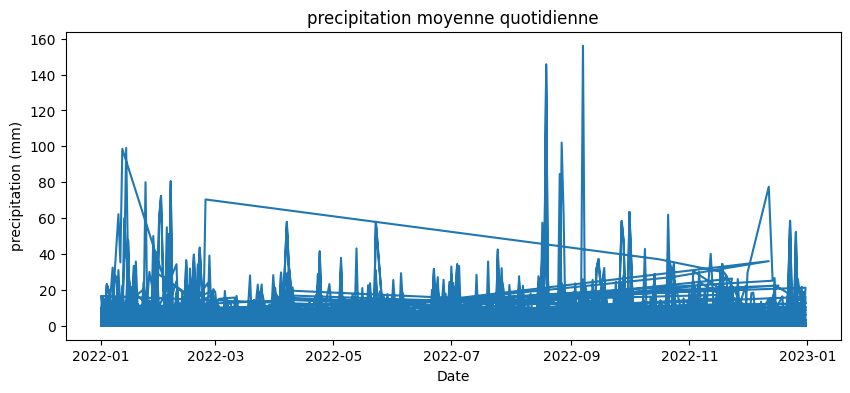

In [45]:

plt.figure(figsize=(10,4))
plt.plot(df_work["date"], df_work["precipitation_mm"])
plt.title("precipitation moyenne quotidienne")
plt.xlabel("Date")
plt.ylabel("precipitation (mm)")
plt.show()

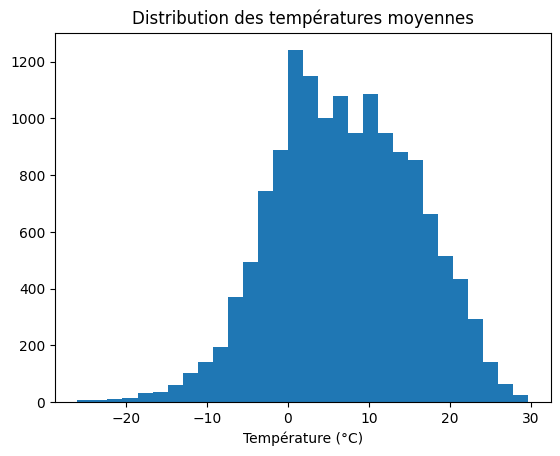

In [46]:
plt.figure()
plt.hist(df_date_index["avg_temp_c"].dropna(), bins=30)
plt.title("Distribution des températures moyennes")
plt.xlabel("Température (°C)")
plt.show()


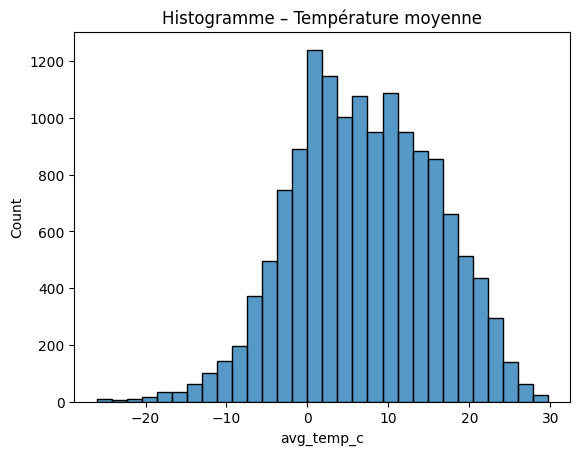

In [47]:
sns.histplot(df_date_index["avg_temp_c"], bins=30)
plt.title("Histogramme – Température moyenne")
plt.show()


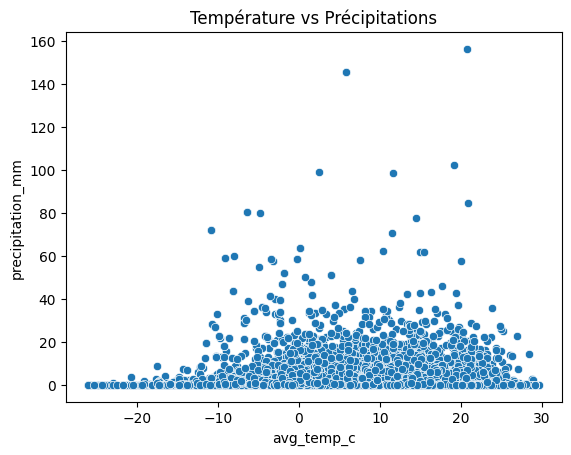

In [48]:
sns.scatterplot(
    data=df_date_index,
    x="avg_temp_c",
    y="precipitation_mm"
)
plt.title("Température vs Précipitations")
plt.show()


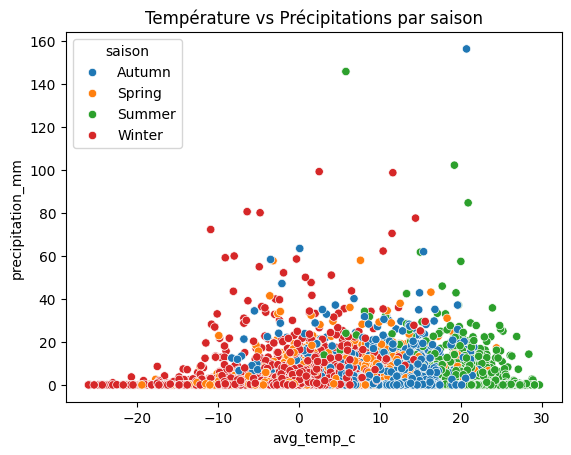

In [49]:
sns.scatterplot(
    data=df_date_index,
    x="avg_temp_c",
    y="precipitation_mm",
    hue="saison"
)
plt.title("Température vs Précipitations par saison")
plt.show()


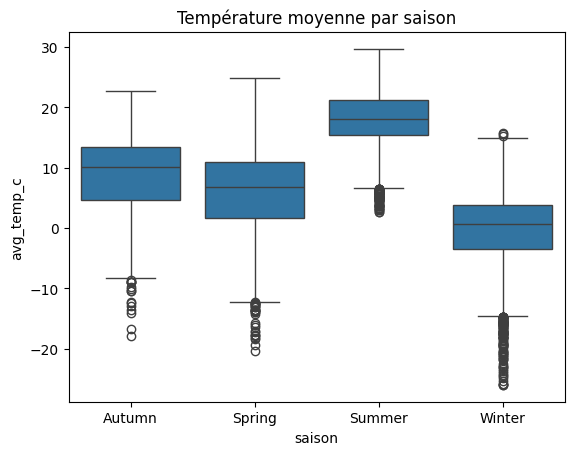

In [50]:
sns.boxplot(
    data=df_date_index,
    x="saison",
    y="avg_temp_c"
)
plt.title("Température moyenne par saison")
plt.show()


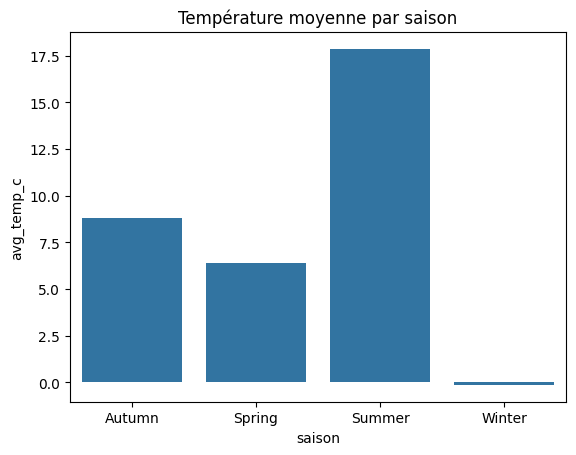

In [51]:
season_mean = df_date_index.groupby("saison")["avg_temp_c"].mean().reset_index()

sns.barplot(
    data=season_mean,
    x="saison",
    y="avg_temp_c"
)
plt.title("Température moyenne par saison")
plt.show()


In [52]:
corr = df_date_index[[
    "avg_temp_c",
    "min_temp_c",
    "max_temp_c",
    "precipitation_mm",
    "avg_wind_speed_kmh"
]].corr()

corr


,avg_temp_c,min_temp_c,max_temp_c,precipitation_mm,avg_wind_speed_kmh
avg_temp_c,1.000000,0.961512,0.977542,-0.022249,-0.163693
min_temp_c,0.961512,1.000000,0.899827,0.014301,-0.101359
max_temp_c,0.977542,0.899827,1.000000,-0.047575,-0.218767
precipitation_mm,-0.022249,0.014301,-0.047575,1.000000,0.214036
avg_wind_speed_kmh,-0.163693,-0.101359,-0.218767,0.214036,1.000000


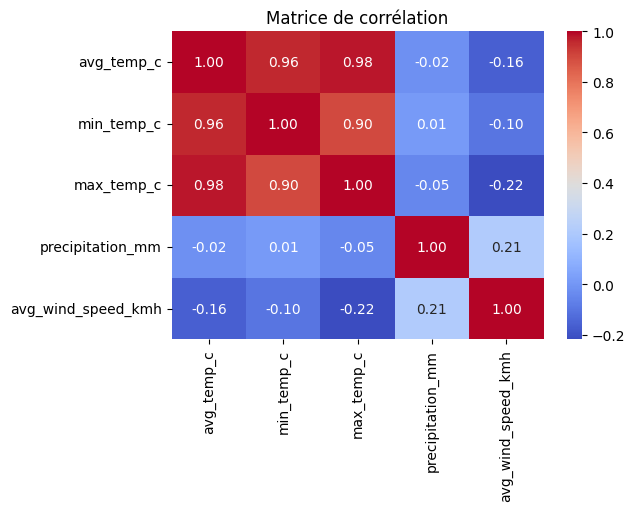

In [53]:
plt.figure(figsize=(6,4))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Matrice de corrélation")
plt.show()


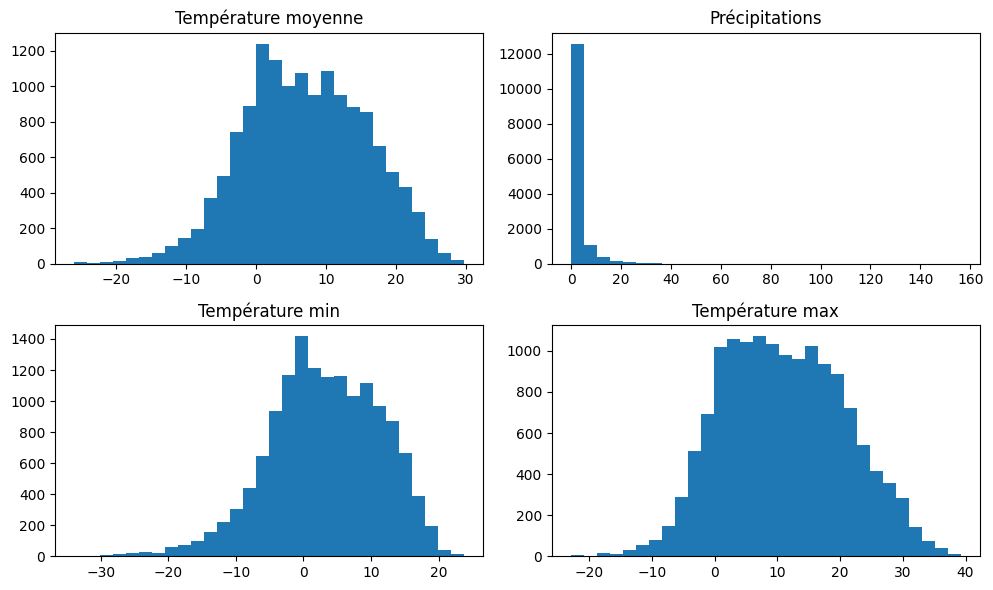

In [54]:
fig, axes = plt.subplots(2, 2, figsize=(10,6))

axes[0,0].hist(df_date_index["avg_temp_c"].dropna(), bins=30)
axes[0,0].set_title("Température moyenne")

axes[0,1].hist(df_date_index["precipitation_mm"].dropna(), bins=30)
axes[0,1].set_title("Précipitations")

axes[1,0].hist(df_date_index["min_temp_c"].dropna(), bins=30)
axes[1,0].set_title("Température min")

axes[1,1].hist(df_date_index["max_temp_c"].dropna(), bins=30)
axes[1,1].set_title("Température max")

plt.tight_layout()
plt.show()


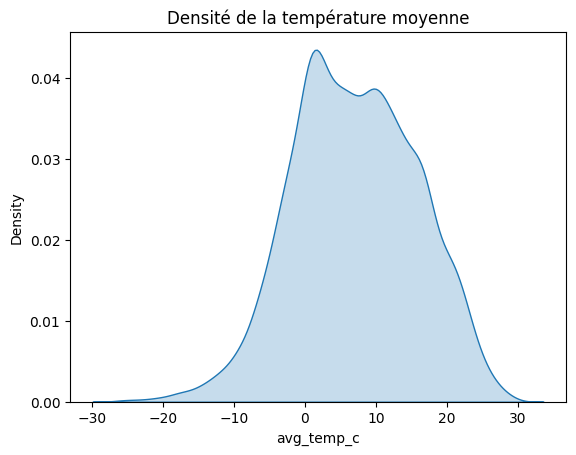

In [55]:
sns.kdeplot(
    data=df_date_index,
    x="avg_temp_c",
    fill=True
)
plt.title("Densité de la température moyenne")
plt.show()
